# Mowing Detection: Standalone Application

This notebook detects mowing events from a pair of Sentinel-2 images using a pre-trained classification model. It is recommended to use the Random Forest Model, but you can also try other model types. This is a simple prototype and works only on Sentinel-2 image data (no Radar) for reasons of and data size and processing complexity.

**Required inputs:**
- A **before** Sentinel-2 GeoTIFF (image taken before the mowing event)
- An **after** Sentinel-2 GeoTIFF (image taken after the mowing event)
- The pre-trained model file, e.g. `s2only_rf.joblib`

**Optional inputs (all default to `None` — safe to leave unset):**
- A **study area** polygon (GeoPackage/Shapefile) to restrict analysis to a specific boundary
- A **grassland mask** (GeoPackage) to restrict analysis to grass-covered areas only
- A **ground truth** polygon file (GeoPackage) with known mowing events for accuracy evaluation

> **Usage:** Run each cell from top to bottom with **Ctrl + Enter**.

---
## Step 1 — Import Required Packages

If any import fails, install the missing package:  

Required packages: `numpy`, `pandas`, `geopandas`, `rasterio`, `joblib`, `matplotlib`, `scikit-learn`, `scikit-image`, `scipy`

In [1]:
%pip install <package-name>

Note: you may need to restart the kernel to use updated packages.


Syntaxfehler.


In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import rasterize as rio_rasterize
import joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from pathlib import Path
from datetime import datetime
from scipy.ndimage import binary_opening, binary_closing, label as ndimage_label

try:
    from skimage.morphology import disk as skdisk
    _DISK_AVAILABLE = True
except ImportError:
    _DISK_AVAILABLE = False
    print("scikit-image not found — using square structuring element for morphological postprocessing.")

print("All packages imported successfully.")

All packages imported successfully.


---
## Step 2 — Configuration

**Edit the paths below.** All optional inputs default to `None` — the pipeline runs correctly whether they are set or not.

In [3]:
# ── REQUIRED: input images and model ─────────────────────────────────────────

# Sentinel-2 GeoTIFF taken BEFORE the mowing event
INPUT_BEFORE = Path("../data/Sentinel_CH/2019-06-19.tif")

# Sentinel-2 GeoTIFF taken AFTER the mowing event
INPUT_AFTER  = Path("../data/Sentinel_CH/2019-06-24.tif")

# Pre-trained model (.joblib)
MODEL_PATH   = Path("../models/s2only_rf.joblib")

# Directory where output files will be saved
OUTPUT_DIR   = Path("../data/operational_results")


# ── OPTIONAL: study area boundary ────────────────────────────────────────────
# Polygon(s) defining the area of interest. Only pixels inside are analysed.
# Set to None to use the full scene extent.

STUDY_AREA_PATH  = None   # e.g. Path("../data/study_area.gpkg")
STUDY_AREA_LAYER = None   # layer name inside GeoPackage; None = first layer / Shapefile


# ── OPTIONAL: grassland mask ──────────────────────────────────────────────────
# GeoPackage with land-cover polygons. Only grassland pixels are analysed.
# Set GRASSLAND_MASK_PATH to None to skip.

GRASSLAND_MASK_PATH    = None   # e.g. Path("../data/amtliche_vermessung_zh/DM01AVZH24LV95.gpkg")
GRASSLAND_LAYER        = None   # e.g. "Bodenbedeckung_BoFlaeche_Area"
GRASSLAND_CLASS_COLUMN = None   # column to filter on, e.g. "Art_TXT"
GRASSLAND_CLASS_VALUE  = None   # value to keep,     e.g. "Wiesen und Weiden"


# ── OPTIONAL: ground truth comparison ────────────────────────────────────────
# Polygon file of known mowing events. Used to evaluate prediction accuracy.
# The polygons should represent areas mowed between the before and after dates.
# Set GROUND_TRUTH_PATH to None to skip evaluation.

GROUND_TRUTH_PATH         = None   # e.g. Path("../data/mowing_events_cleaned.gpkg")
GROUND_TRUTH_LAYER        = None   # layer name, e.g. "events_cleaned"; None = first layer
GROUND_TRUTH_DATE_COLUMN  = None   # date column for filtering events to the scene window
                                   # e.g. "date"; None = use ALL polygons in the file


# ── ADVANCED: image band layout and postprocessing ───────────────────────────
CLOUD_BAND         = 13   # 1-based band index for the cloud probability layer
CLOUD_THRESHOLD    = 30   # cloud probability threshold (%); pixels above are excluded
PP_DISK_RADIUS     = 1    # morphological structuring element radius (pixels)
PP_MIN_AREA_PIXELS = 2    # minimum mowing patch area to keep (pixels)
PP_MEDIAN_SIZE     = 3    # median pre-filter window (0 = disabled, 3/5/7 = window size)

# ─────────────────────────────────────────────────────────────────────────────
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Before image : {INPUT_BEFORE}")
print(f"After  image : {INPUT_AFTER}")
print(f"Model        : {MODEL_PATH}")
print(f"Output dir   : {OUTPUT_DIR}")
print()
print(f"Study area   : {STUDY_AREA_PATH or 'not set (full scene)'}")
print(f"Grassland    : {GRASSLAND_MASK_PATH or 'not set (all land cover)'}")
print(f"Ground truth : {GROUND_TRUTH_PATH or 'not set (no evaluation)'}")

Before image : ..\data\Sentinel_CH\2019-06-19.tif
After  image : ..\data\Sentinel_CH\2019-06-24.tif
Model        : ..\models\s2only_rf.joblib
Output dir   : ..\data\operational_results

Study area   : not set (full scene)
Grassland    : not set (all land cover)
Ground truth : not set (no evaluation)


---
## Step 3 — Helper Functions

Defines all functions used by the pipeline. No changes needed here — just run the cell.

In [4]:
# ── Vegetation indices ────────────────────────────────────────────────────────

def calculate_evi(nir, red, blue):
    with np.errstate(divide='ignore', invalid='ignore'):
        r = 2.5 * ((nir - red) / (nir + 6 * red - 7.5 * blue + 1))
    r[np.isinf(r)] = np.nan
    return r

def calculate_gndvi(nir, green):
    with np.errstate(divide='ignore', invalid='ignore'):
        r = (nir - green) / (nir + green)
    r[np.isinf(r)] = np.nan
    return r

def calculate_ndii(nir, swir):
    with np.errstate(divide='ignore', invalid='ignore'):
        r = (nir - swir) / (nir + swir)
    r[np.isinf(r)] = np.nan
    return r


# ── Morphological postprocessing ──────────────────────────────────────────────

def apply_median_filter(pred_map, size=3):
    """Median pre-filter to remove salt-and-pepper noise. Preserves nodata pixels."""
    from scipy.ndimage import median_filter as scipy_median_filter
    nodata_mask = (pred_map == -1)
    filtered = scipy_median_filter(
        np.where(nodata_mask, 0, pred_map).astype(np.float32), size=size)
    result = (filtered >= 0.5).astype(np.int8)
    result[nodata_mask] = -1
    return result

def apply_morphological_clean(pred_map, disk_radius=2, min_area_pixels=4):
    """
    Binary opening + closing then minimum-area filter.
    pred_map: 2-D int8 array with values {-1 (nodata), 0, 1}
    """
    nodata_mask = (pred_map == -1)
    binary = (pred_map == 1)
    struct = skdisk(disk_radius) if _DISK_AVAILABLE else np.ones(
        (2 * disk_radius + 1, 2 * disk_radius + 1), dtype=bool)
    opened = binary_opening(binary, structure=struct)
    closed = binary_closing(opened, structure=struct)
    labeled, n_comp = ndimage_label(closed)
    for cid in range(1, n_comp + 1):
        if np.sum(labeled == cid) < min_area_pixels:
            closed[labeled == cid] = False
    result = closed.astype(np.int8)
    result[nodata_mask] = -1
    return result


# ── Spatial masking from vector files ─────────────────────────────────────────

def build_vector_mask(vector_path, layer, target_crs, transform, H, W,
                      filter_column=None, filter_value=None):
    """
    Read a vector file, optionally filter rows by a column value, reproject to
    target_crs, and rasterize to a flat boolean mask on the prediction grid.

    Returns a 1-D boolean array of length H*W.
    """
    gdf = gpd.read_file(str(vector_path), layer=layer)
    print(f"    Loaded {len(gdf)} features from '{vector_path.name}' (CRS: {gdf.crs})")
    gdf = gdf.to_crs(target_crs)
    if filter_column is not None and filter_value is not None:
        gdf = gdf[gdf[filter_column] == filter_value]
        print(f"    After filter '{filter_column}' == '{filter_value}': {len(gdf)} features")
    if len(gdf) == 0:
        print("    WARNING: no features remain after filtering — mask will be all-False.")
        return np.zeros(H * W, dtype=bool)
    mask_2d = rio_rasterize(
        shapes=((geom, 1) for geom in gdf.geometry if geom is not None),
        out_shape=(H, W),
        transform=transform,
        fill=0,
        dtype='uint8',
        all_touched=False,
    )
    return mask_2d.astype(bool).flatten()


# ── Feature computation ───────────────────────────────────────────────────────

def compute_features(before_path, after_path, cloud_band=13, cloud_threshold=30):
    """
    Load a before/after Sentinel-2 pair and compute the 7 features required
    by the s2only_rf model. Also checks that both images share the same CRS.

    Band layout (1-based): 1=Blue, 2=Green, 3=Red, 7=NIR(B8), 10=SWIR(B11), 13=Cloud

    Returns
    -------
    feature_df : DataFrame with model feature columns (NaN for invalid pixels)
    valid_mask : 1-D boolean array (H*W) — non-cloudy, non-NaN pixels
    meta       : rasterio metadata dict (CRS, transform, shape)
    H, W       : scene height and width
    rgb_after  : (H, W, 3) uint8 array for visualisation (R-G-B order)
    """
    with rasterio.open(str(before_path)) as src_b, \
         rasterio.open(str(after_path)) as src_a:

        if src_b.crs != src_a.crs:
            raise ValueError(
                f"CRS mismatch between before ({src_b.crs}) and after ({src_a.crs}) images. "
                "Reproject them to the same CRS before running this notebook."
            )

        meta = src_b.meta.copy()
        H, W = meta['height'], meta['width']

        # Read as float reflectance (Sentinel-2 DN / 10000)
        blue_b  = src_b.read(1).astype(float) / 10000.0
        green_b = src_b.read(2).astype(float) / 10000.0
        red_b   = src_b.read(3).astype(float) / 10000.0
        nir_b   = src_b.read(7).astype(float) / 10000.0
        swir_b  = src_b.read(10).astype(float) / 10000.0
        cloud_b = src_b.read(cloud_band).astype(float)

        blue_a  = src_a.read(1).astype(float) / 10000.0
        green_a = src_a.read(2).astype(float) / 10000.0
        red_a   = src_a.read(3).astype(float) / 10000.0
        nir_a   = src_a.read(7).astype(float) / 10000.0
        swir_a  = src_a.read(10).astype(float) / 10000.0
        cloud_a = src_a.read(cloud_band).astype(float)

    ndii_b  = calculate_ndii(nir_b,  swir_b)
    ndii_a  = calculate_ndii(nir_a,  swir_a)
    gndvi_b = calculate_gndvi(nir_b, green_b)
    gndvi_a = calculate_gndvi(nir_a, green_a)
    evi_b   = calculate_evi(nir_b,   red_b,  blue_b)
    evi_a   = calculate_evi(nir_a,   red_a,  blue_a)

    feature_df = pd.DataFrame({
        'ndii_diff':   (ndii_a  - ndii_b ).flatten(),
        'gndvi_diff':  (gndvi_a - gndvi_b).flatten(),
        'ndii_after':  ndii_a.flatten(),
        'swir_after':  swir_a.flatten(),
        'evi_diff':    (evi_a   - evi_b  ).flatten(),
        'green_after': green_a.flatten(),
        'swir_diff':   (swir_a  - swir_b ).flatten(),
    })

    cloud_mask = ((cloud_b > cloud_threshold) | (cloud_a > cloud_threshold)).flatten()
    nan_mask   = np.isnan(feature_df.values).any(axis=1)
    valid_mask = ~cloud_mask & ~nan_mask

    # Stretch to 0-255 for visualisation (2%-98% percentile clip)
    def _stretch(arr):
        lo, hi = np.nanpercentile(arr, (2, 98))
        return np.clip((arr - lo) / (hi - lo + 1e-9), 0, 1)
    rgb_after = (np.stack([_stretch(red_a), _stretch(green_a), _stretch(blue_a)], axis=-1) * 255).astype(np.uint8)

    return feature_df, valid_mask, meta, H, W, rgb_after


print("Helper functions defined.")

Helper functions defined.


---
## Step 4 — Load Pre-trained Model

In [5]:
model_obj = joblib.load(MODEL_PATH)
model     = model_obj['model']      # sklearn Pipeline (StandardScaler + RandomForestClassifier)
features  = model_obj['features']   # list of feature names the model was trained on
threshold = model_obj['threshold']  # calibrated decision threshold

print(f"Model loaded : {MODEL_PATH.name}")
print(f"  Features ({len(features)}): {features}")
print(f"  Decision threshold: {threshold:.4f}")

Model loaded : s2only_rf.joblib
  Features (7): ['ndii_diff', 'gndvi_diff', 'ndii_after', 'swir_after', 'evi_diff', 'green_after', 'swir_diff']
  Decision threshold: 0.9000


---
## Step 5 — Load Images and Compute Features

Reads both Sentinel-2 images, verifies they share the same CRS, applies cloud masking,
and computes vegetation index features.

In [6]:
print("Loading images and computing features...")

feature_df, valid_mask, meta, H, W, rgb_after = compute_features(
    INPUT_BEFORE, INPUT_AFTER,
    cloud_band=CLOUD_BAND,
    cloud_threshold=CLOUD_THRESHOLD,
)

scene_crs       = meta['crs']
scene_transform = meta['transform']
pixel_area_m2   = abs(scene_transform.a * scene_transform.e)

n_total  = H * W
n_cloudy = n_total - int(valid_mask.sum())

print(f"CRS             : {scene_crs}")
print(f"Pixel size      : {scene_transform.a:.1f} m x {abs(scene_transform.e):.1f} m")
print(f"Scene dimensions: {H} x {W} = {n_total:,} pixels")
print(f"Cloudy / masked : {n_cloudy:,} pixels ({100 * n_cloudy / n_total:.1f}%)")
print(f"Cloud-free      : {int(valid_mask.sum()):,} pixels ({100 * valid_mask.mean():.1f}%)")

if valid_mask.sum() == 0:
    raise RuntimeError("No cloud-free pixels found. Check CLOUD_BAND and CLOUD_THRESHOLD.")

Loading images and computing features...
CRS             : EPSG:2056
Pixel size      : 10.0 m x 10.0 m
Scene dimensions: 559 x 381 = 212,979 pixels
Cloudy / masked : 19,480 pixels (9.1%)
Cloud-free      : 193,499 pixels (90.9%)


---
## Step 6 — Apply Optional Spatial Masks

Restricts the analysis to the study area and/or grassland pixels.
If neither is set this cell does nothing and the full cloud-free scene is used.

In [7]:
# Start from the cloud-based mask produced in the previous step
analysis_mask = valid_mask.copy()

# ── Optional: study area boundary ────────────────────────────────────────────
if STUDY_AREA_PATH is not None:
    print("Applying study area mask...")
    sa_mask = build_vector_mask(
        Path(STUDY_AREA_PATH), STUDY_AREA_LAYER,
        scene_crs, scene_transform, H, W,
    )
    n_before = int(analysis_mask.sum())
    analysis_mask = analysis_mask & sa_mask
    print(f"  Study area pixels        : {int(sa_mask.sum()):,}")
    print(f"  Valid pixels after filter: {int(analysis_mask.sum()):,}  "
          f"(removed {n_before - int(analysis_mask.sum()):,})")
else:
    print("Study area mask : not set (using full scene extent).")

# ── Optional: grassland mask ──────────────────────────────────────────────────
if GRASSLAND_MASK_PATH is not None:
    print("Applying grassland mask...")
    grass_mask = build_vector_mask(
        Path(GRASSLAND_MASK_PATH), GRASSLAND_LAYER,
        scene_crs, scene_transform, H, W,
        filter_column=GRASSLAND_CLASS_COLUMN,
        filter_value=GRASSLAND_CLASS_VALUE,
    )
    n_before = int(analysis_mask.sum())
    analysis_mask = analysis_mask & grass_mask
    print(f"  Grassland pixels         : {int(grass_mask.sum()):,}")
    print(f"  Valid pixels after filter: {int(analysis_mask.sum()):,}  "
          f"(removed {n_before - int(analysis_mask.sum()):,})")
else:
    print("Grassland mask  : not set (predicting over all land cover types).")

# Update valid_mask so downstream cells pick up the spatial restrictions
valid_mask = analysis_mask
n_valid    = int(valid_mask.sum())

print(f"\nFinal valid pixels for prediction: {n_valid:,} "
      f"({100 * n_valid / n_total:.1f}% of scene)")

if n_valid == 0:
    raise RuntimeError("No valid pixels remain after spatial filtering. Check your mask inputs.")

Study area mask : not set (using full scene extent).
Grassland mask  : not set (predicting over all land cover types).

Final valid pixels for prediction: 193,499 (90.9% of scene)


---
## Step 7 — Run Mowing Detection

Applies the model to every valid pixel, thresholds the probability output, and
cleans the result with morphological postprocessing.

In [8]:
print("Running model prediction...")

proba_flat = np.full(H * W, np.nan, dtype=np.float32)
proba_flat[valid_mask] = model.predict_proba(feature_df.loc[valid_mask, features])[:, 1]

# -1 = nodata (outside valid mask)
pred_flat = np.full(H * W, -1, dtype=np.int8)
pred_flat[valid_mask] = (proba_flat[valid_mask] >= threshold).astype(np.int8)

pred_map_raw = pred_flat.reshape(H, W)

n_mowed_raw = int((pred_flat == 1).sum())
print(f"  Raw prediction           : {n_mowed_raw:,} mowed pixels "
      f"({100 * n_mowed_raw / n_valid:.2f}% of valid area)")

APPLY_POSTPROCESSING = True
if APPLY_POSTPROCESSING:
    print("Applying postprocessing...")
    pred_map_pp = pred_map_raw.copy()
    if PP_MEDIAN_SIZE > 0:
        pred_map_pp = apply_median_filter(pred_map_pp, size=PP_MEDIAN_SIZE)
    pred_map_pp = apply_morphological_clean(
        pred_map_pp, disk_radius=PP_DISK_RADIUS, min_area_pixels=PP_MIN_AREA_PIXELS)
else:
    pred_map_pp = pred_map_raw.copy()

n_mowed_pp = int((pred_map_pp == 1).sum())
print(f"  After postprocessing     : {n_mowed_pp:,} mowed pixels "
      f"({100 * n_mowed_pp / n_valid:.2f}% of valid area)")
print("Done.")

Running model prediction...
  Raw prediction           : 5,889 mowed pixels (3.04% of valid area)
Applying postprocessing...
  After postprocessing     : 4,438 mowed pixels (2.29% of valid area)
Done.


---
## Step 8 — Visualise Results

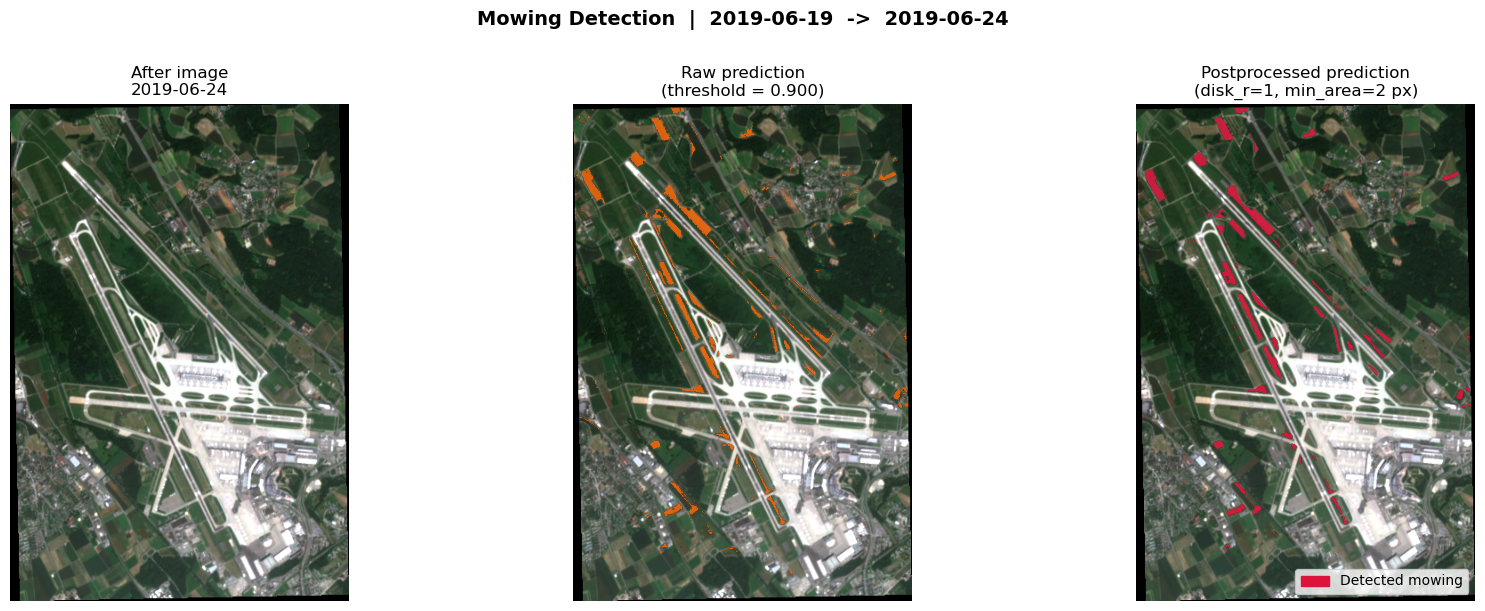

Visualisation saved to: ..\data\operational_results\detection_2019-06-24_visualisation.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: RGB after image
axes[0].imshow(rgb_after)
axes[0].set_title(f"After image\n{INPUT_AFTER.stem}", fontsize=12)
axes[0].axis('off')

# Panel 2: Raw prediction overlay
raw_rgba = np.zeros((H, W, 4), dtype=np.uint8)
raw_rgba[pred_map_raw == 1] = [255, 100, 0, 200]
axes[1].imshow(rgb_after)
axes[1].imshow(raw_rgba)
axes[1].set_title(f"Raw prediction\n(threshold = {threshold:.3f})", fontsize=12)
axes[1].axis('off')

# Panel 3: Postprocessed prediction overlay
pp_rgba = np.zeros((H, W, 4), dtype=np.uint8)
pp_rgba[pred_map_pp == 1] = [220, 20, 60, 220]
axes[2].imshow(rgb_after)
axes[2].imshow(pp_rgba)
patch = mpatches.Patch(color=(220/255, 20/255, 60/255), label='Detected mowing')
axes[2].legend(handles=[patch], loc='lower right', fontsize=10)
axes[2].set_title(
    f"Postprocessed prediction\n"
    f"(disk_r={PP_DISK_RADIUS}, min_area={PP_MIN_AREA_PIXELS} px)", fontsize=12)
axes[2].axis('off')

fig.suptitle(
    f"Mowing Detection  |  {INPUT_BEFORE.stem}  ->  {INPUT_AFTER.stem}",
    fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()

fig_path = OUTPUT_DIR / f"detection_{INPUT_AFTER.stem}_visualisation.png"
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Visualisation saved to: {fig_path}")

---
## Step 9 — Save Prediction as GeoTIFF

Pixel values: **1 = mowed**, **0 = not mowed**, **255 = no data (cloudy / outside mask)**.

In [22]:
output_path = OUTPUT_DIR / f"mowing_detection_{INPUT_AFTER.stem}.tif"

out_meta = meta.copy()
out_meta.update({'count': 1, 'dtype': 'uint8', 'nodata': 255, 'compress': 'lzw'})

out_arr = pred_map_pp.astype(np.uint8)
out_arr[pred_map_pp == -1] = 255  # nodata

with rasterio.open(str(output_path), 'w', **out_meta) as dst:
    dst.write(out_arr, 1)
    dst.update_tags(
        BEFORE_IMAGE=INPUT_BEFORE.name,
        AFTER_IMAGE=INPUT_AFTER.name,
        MODEL=MODEL_PATH.name,
        THRESHOLD=str(round(threshold, 6)),
        POSTPROCESSING=f"morphological disk_r={PP_DISK_RADIUS} min_area={PP_MIN_AREA_PIXELS}",
        CREATED=datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    )

print(f"Prediction saved to: {output_path}")
print(f"  Encoding: 1=mowed, 0=not mowed, 255=no data")

Prediction saved to: ..\data\operational_results\mowing_detection_2019-06-24.tif
  Encoding: 1=mowed, 0=not mowed, 255=no data


---
## Step 10 — Ground Truth Comparison (Optional)

Only runs when `GROUND_TRUTH_PATH` is set.  
Rasterizes the GT polygons to the prediction grid, computes precision / recall / F1,
and shows a TP / FP / FN comparison map.

In [ ]:
if GROUND_TRUTH_PATH is None:
    print("No ground truth provided — skipping evaluation.")
    print("Set GROUND_TRUTH_PATH in Step 2 to enable accuracy assessment.")
else:
    print("Ground truth evaluation...")

    # ── Load and optionally filter GT polygons ────────────────────────────────
    gt_gdf = gpd.read_file(str(GROUND_TRUTH_PATH), layer=GROUND_TRUTH_LAYER)
    print(f"  Loaded {len(gt_gdf)} features from '{Path(GROUND_TRUTH_PATH).name}' (CRS: {gt_gdf.crs})")
    gt_gdf = gt_gdf.to_crs(scene_crs)

    if GROUND_TRUTH_DATE_COLUMN is not None:
        # Parse scene window dates from filenames (expected format YYYY-MM-DD)
        try:
            date_before = datetime.strptime(INPUT_BEFORE.stem, '%Y-%m-%d').date()
            date_after  = datetime.strptime(INPUT_AFTER.stem,  '%Y-%m-%d').date()
            dates_ok = True
        except ValueError:
            print("  WARNING: could not parse dates from filenames — using all GT polygons without date filter.")
            dates_ok = False

        if dates_ok:
            gt_gdf[GROUND_TRUTH_DATE_COLUMN] = pd.to_datetime(
                gt_gdf[GROUND_TRUTH_DATE_COLUMN], errors='coerce').dt.date
            n_before_filter = len(gt_gdf)
            gt_gdf = gt_gdf[
                (gt_gdf[GROUND_TRUTH_DATE_COLUMN] > date_before) &
                (gt_gdf[GROUND_TRUTH_DATE_COLUMN] <= date_after)
            ]
            print(f"  Date filter {date_before} < date <= {date_after}: "
                  f"{len(gt_gdf)} of {n_before_filter} features kept")
    else:
        print("  GROUND_TRUTH_DATE_COLUMN not set — using all polygons in the file.")

    if len(gt_gdf) == 0:
        print("  No GT polygons remain after filtering — skipping evaluation.")
    else:
        # ── Rasterize GT to prediction grid ──────────────────────────────────
        gt_mask_2d = rio_rasterize(
            shapes=((geom, 1) for geom in gt_gdf.geometry if geom is not None),
            out_shape=(H, W),
            transform=scene_transform,
            fill=0,
            dtype='uint8',
            all_touched=False,
        )
        gt_flat = gt_mask_2d.flatten().astype(bool)

        # Evaluate only on valid (non-nodata) pixels
        eval_mask = valid_mask
        y_true = gt_flat[eval_mask].astype(int)
        y_pred = (pred_map_pp.flatten()[eval_mask] == 1).astype(int)

        prec = precision_score(y_true, y_pred, zero_division=0)
        rec  = recall_score(y_true, y_pred, zero_division=0)
        f1   = f1_score(y_true, y_pred, zero_division=0)

        print(f"\n  GT mowed pixels : {int(gt_flat[eval_mask].sum()):,}")
        print(f"  Pred mowed pixels: {int(y_pred.sum()):,}")
        print()
        print(f"  Precision : {prec:.3f}")
        print(f"  Recall    : {rec:.3f}")
        print(f"  F1 score  : {f1:.3f}")
        print()
        print(classification_report(y_true, y_pred,
                                    target_names=['not mowed', 'mowed'],
                                    zero_division=0))

        # ── TP / FP / FN visualisation ────────────────────────────────────────
        # 1=TP (cyan), 2=FP (orange), 3=FN (magenta); NaN=not evaluated
        category = np.full(H * W, np.nan, dtype=float)
        p = (pred_map_pp.flatten() == 1)
        g = gt_flat
        vm = valid_mask
        category[vm &  p[vm] &  g[vm]] = 1   # TP
        category[vm &  p[vm] & ~g[vm]] = 2   # FP
        category[vm & ~p[vm] &  g[vm]] = 3   # FN
        category_map = category.reshape(H, W)

        from matplotlib.colors import ListedColormap
        cmap_eval = ListedColormap(['#00CCFF', '#FF9900', '#FF00FF'])

        fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))

        axes2[0].imshow(rgb_after)
        gt_rgba = np.zeros((H, W, 4), dtype=np.uint8)
        gt_rgba[gt_mask_2d == 1] = [255, 215, 0, 200]   # gold
        axes2[0].imshow(gt_rgba)
        axes2[0].set_title("Ground truth\n(gold = mowed)", fontsize=12)
        axes2[0].axis('off')

        axes2[1].imshow(rgb_after)
        axes2[1].imshow(category_map, cmap=cmap_eval, vmin=0.5, vmax=3.5, alpha=0.75)
        patches = [
            mpatches.Patch(color='#00CCFF', label=f'TP ({int((category==1).sum()):,})'),
            mpatches.Patch(color='#FF9900', label=f'FP ({int((category==2).sum()):,})'),
            mpatches.Patch(color='#FF00FF', label=f'FN ({int((category==3).sum()):,})'),
        ]
        axes2[1].legend(handles=patches, loc='lower right', fontsize=9)
        axes2[1].set_title(f"TP / FP / FN map\nF1={f1:.3f}  P={prec:.3f}  R={rec:.3f}",
                           fontsize=12)
        axes2[1].axis('off')

        fig2.suptitle(
            f"Accuracy Evaluation  |  {INPUT_BEFORE.stem}  ->  {INPUT_AFTER.stem}",
            fontsize=14, fontweight='bold', y=1.01)
        plt.tight_layout()

        eval_fig_path = OUTPUT_DIR / f"evaluation_{INPUT_AFTER.stem}.png"
        plt.savefig(eval_fig_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Evaluation map saved to: {eval_fig_path}")

---
## Step 11 — Summary

In [23]:
mowed_ha = n_mowed_pp * pixel_area_m2 / 10_000
valid_ha  = n_valid   * pixel_area_m2 / 10_000
scene_ha  = n_total   * pixel_area_m2 / 10_000

print("=" * 56)
print(" MOWING DETECTION SUMMARY")
print("=" * 56)
print(f" Before image     : {INPUT_BEFORE.name}")
print(f" After  image     : {INPUT_AFTER.name}")
print(f" Model            : {MODEL_PATH.name}")
print(f" Decision threshold: {threshold:.4f}")
print(f" CRS              : {scene_crs}")
print(f" Pixel size       : {pixel_area_m2:.0f} m2")
print("-" * 56)
print(f" Scene area       : {scene_ha:.1f} ha  ({n_total:,} px)")
print(f" Valid for analysis: {valid_ha:.1f} ha  ({n_valid:,} px)")
print(f" Detected mowing  : {mowed_ha:.2f} ha  ({n_mowed_pp:,} px)")
print(f" Coverage         : {100 * n_mowed_pp / n_valid:.2f}% of valid area")
print("-" * 56)
print(f" Study area mask  : {'yes — ' + str(STUDY_AREA_PATH) if STUDY_AREA_PATH else 'no'}")
print(f" Grassland mask   : {'yes — ' + str(GRASSLAND_MASK_PATH) if GRASSLAND_MASK_PATH else 'no'}")
print(f" Ground truth eval: {'yes — ' + str(GROUND_TRUTH_PATH) if GROUND_TRUTH_PATH else 'no'}")
print("-" * 56)
print(f" Output           : {output_path}")
print("=" * 56)

 MOWING DETECTION SUMMARY
 Before image     : 2019-06-19.tif
 After  image     : 2019-06-24.tif
 Model            : s2only_rf.joblib
 Decision threshold: 0.9000
 CRS              : EPSG:2056
 Pixel size       : 100 m2
--------------------------------------------------------
 Scene area       : 2131.6 ha  (212,979 px)
 Valid for analysis: 1936.7 ha  (193,499 px)
 Detected mowing  : 31.51 ha  (3,148 px)
 Coverage         : 1.63% of valid area
--------------------------------------------------------
 Study area mask  : no
 Grassland mask   : no
 Ground truth eval: no
--------------------------------------------------------
 Output           : ..\data\operational_results\mowing_detection_2019-06-24.tif
